# ICU Stress Early-Warning Modeling — Controlled Experimental Framework

## Purpose

This notebook implements a **controlled experimental framework** to evaluate early-warning models for ICU stress and compare them against a heuristic baseline. Two logistic regression models are tested: **v1** (minimal ICU features) and **v2** (ICU + respiratory signals), both under strict safeguards.

## How This Notebook Differs from `feature_eng_modeling.ipynb`

`feature_eng_modeling` served a different purpose: it was a **feature engineering and iterative modeling** notebook that explored which upstream respiratory signals carry predictive value, diagnosed multicollinearity, and progressively built models (v1 signals-only, v2 signals+momentum+smoothed) to assess whether respiratory demand features provide early warning. Its goal was **signal discovery and model iteration**, not controlled evaluation.

This notebook is a **controlled experimental framework** that applies the same safeguards to both a minimal ICU model (v1) and an extended respiratory model (v2), enabling a direct comparison under identical conditions.

| Aspect | `feature_eng_modeling` | This notebook |
|---|---|---|
| **Intent** | Feature engineering & iterative modeling — signal discovery, multicollinearity diagnosis, progressive model building (v1, v2) | Strictly **controlled evaluation** — v1 (ICU-only) vs v2 (ICU + respiratory) vs heuristic |
| **Threshold** | Computed on full post-cutoff dataset (acceptable for iterative exploration) | Computed **only on training window** — locked and never recomputed (leakage prevention) |
| **Features** | Respiratory signals, COVID burden, smoothed 7-day means, ICU momentum — iteratively expanded | v1: 2 ICU features; v2: 2 ICU + 5 respiratory signals (log1p) |
| **Baseline** | Persistence-based (rolling 7-day max ≥ threshold) — reactive, not early-warning | **Early-warning heuristic** (proximity to threshold + positive trend) — triggers before crossing |
| **Models** | Logistic regression: v1 (signals only), v2 (signals + momentum + smoothed) — model iteration | Logistic regression v1 + v2 — controlled comparison under identical split and threshold |
| **Evaluation** | Expanding-window walk-forward on each new day — progressive retraining | Strict **train/test time split** — single fixed boundary, no shuffle, no data leakage |

## Constraints

- No exploratory code reused from `feature_eng_modeling`
- No threshold recomputation on full data
- No time-series shuffling
- No tree-based models (Random Forest, Gradient Boosting)
- Forward-looking label and backward-looking features are strictly aligned
- All evaluation on unseen test period only

## 1. Data Loading & Structural Regime Definition

### What This Section Does
Loads the cleaned HHS dataset, restricts it to the post-Omicron regime (starting 2022-06-01), and performs structural integrity checks.

### Why It Is Necessary
The early pandemic period introduced extreme volatility, policy shocks, and structural changes that no longer reflect current ICU dynamics. Restricting to the post-Omicron regime ensures the model learns from operationally stable and relevant patterns.

### How This Differs from `feature_eng_modeling`
- This notebook is **not exploratory** — no feature visualization or multicollinearity analysis
- It is strictly **modeling and evaluation-focused**
- No threshold or labels are computed yet at this stage

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

# Reproducibility
np.random.seed(42)

In [2]:
# ── Load cleaned dataset ──
data_dir = Path("..") / "data"
data = pd.read_parquet(data_dir / "hhs_cleaned.parquet")

# ── Restrict to post-Omicron regime ──
REGIME_CUTOFF = "2022-06-01"
data = data.loc[REGIME_CUTOFF:]

# ── Ensure datetime index integrity ──
assert isinstance(data.index, pd.DatetimeIndex), "Index must be DatetimeIndex"
data = data.sort_index()

# ── Check for duplicates ──
n_dupes = data.index.duplicated().sum()
print(f"Duplicate index entries: {n_dupes}")
assert n_dupes == 0, "Duplicate dates detected — resolve before proceeding"

# ── Check for missing ICU utilization ──
icu_col = "adult_icu_bed_utilization"
n_missing_icu = data[icu_col].isna().sum()
print(f"Missing ICU utilization values: {n_missing_icu}")
assert n_missing_icu == 0, "Missing ICU utilization — cannot proceed without target signal"

print(f"\nRegime window: {data.index.min().date()} to {data.index.max().date()}")
print(f"Total observations: {len(data)}")
print(f"Columns: {list(data.columns)}")

Duplicate index entries: 0
Missing ICU utilization values: 0

Regime window: 2022-06-01 to 2024-04-27
Total observations: 697
Columns: ['icu_patients_confirmed_influenza', 'adult_icu_bed_utilization', 'inpatient_beds_used_covid', 'total_patients_hospitalized_confirmed_influenza', 'adult_icu_bed_covid_utilization', 'previous_day_admission_influenza_confirmed', 'previous_day_admission_adult_covid_confirmed_and_suspected', 'total_adult_patients_hospitalized_covid']


## 2. Initial Training Window Definition

### What This Section Does
Defines the initial training window as the **first 365 days** after the regime cutoff. This window serves two purposes:
1. **Compute the ICU stress threshold** (85th percentile) — locked and never recomputed
2. **Serve as the initial training block** for the logistic regression model

### Why It Is Necessary
Computing the threshold on the training window only prevents **distribution leakage** — if we used the full dataset, the threshold would incorporate future information that would not be available at deployment time.

### How This Differs from `feature_eng_modeling`
In `feature_eng_modeling`, the threshold was computed on the **full post-cutoff dataset** for exploratory purposes. Here, we enforce strict temporal separation: the threshold is derived **only from data available at the start of the evaluation period**, simulating real-world deployment where future utilization is unknown.

> **Clarification:** We are preventing distribution leakage. In deployment, the threshold would be set using historical data available at go-live time. It would not be recalculated as new data arrives.

In [3]:
# ── Define initial training window: first 365 days ──
TRAIN_DAYS = 365
train_end_date = data.index.min() + pd.Timedelta(days=TRAIN_DAYS - 1)

train_window_raw = data.loc[:train_end_date]

print(f"Training window:  {train_window_raw.index.min().date()} to {train_window_raw.index.max().date()}  ({len(train_window_raw)} days)")
print(f"Test window:      after {train_end_date.date()}")
print(f"\nThis training window will be used to:")
print(f"  1. Compute ICU stress threshold (85th percentile)")
print(f"  2. Serve as the initial training block for the logistic regression model")

Training window:  2022-06-01 to 2023-05-31  (365 days)
Test window:      after 2023-05-31

This training window will be used to:
  1. Compute ICU stress threshold (85th percentile)
  2. Serve as the initial training block for the logistic regression model


## 3. Compute ICU Stress Threshold (Training Window Only)

### What This Section Does
Computes the **85th percentile** of adult ICU bed utilization from the initial training window only. This value is stored as a **fixed scalar** and will never be recomputed.

### Why Threshold Must Be Computed on Training Only
- Using the full dataset would leak future distributional information into the label definition, inflating apparent model performance.
- This mimics real-world deployment where the threshold is set using historical data available at system launch.

### Why 85th Percentile
- Represents **sustained operational strain** rather than rare catastrophic overload.
- Produces a balanced-enough positive class for reliable classification.
- Comparable to the threshold used in `feature_eng_modeling` for interpretive continuity.

### Operational Translation
The computed percentile translates directly to a utilization percentage that hospital administrators can interpret: e.g., "alert when projected utilization exceeds X%."

> **This threshold is LOCKED.** It will NOT be recomputed when expanding the training window or evaluating the test set. This prevents distribution leakage and mimics real-world deployment.

In [4]:
# ── Compute threshold from training window ONLY ──
ICU_PERCENTILE = 0.85
STRESS_THRESHOLD = train_window_raw[icu_col].quantile(ICU_PERCENTILE)

print(f"ICU Stress Threshold (locked)")
print(f"  Percentile:          {ICU_PERCENTILE:.0%}")
print(f"  Utilization value:   {STRESS_THRESHOLD:.4f}  ({STRESS_THRESHOLD * 100:.2f}%)")
print(f"  Computed from:       {len(train_window_raw)} training-window observations")

# ── Definition ──
print(f"\n  Definition:")
print(f"  ICU stress is defined as adult ICU bed utilization exceeding")
print(f"  {STRESS_THRESHOLD * 100:.1f}% at any point in the next 7 days.")
print(f"  This corresponds to the {ICU_PERCENTILE * 100:.0f}th percentile of utilization")
print(f"  observed during the training period")
print(f"  ({train_window_raw.index.min().date()} to {train_window_raw.index.max().date()}).")
print(f"  The early-warning model is trained to predict this event.")

# ── Training distribution context ──
print(f"\n  Training Distribution Context:")
print(f"    Mean utilization:    {train_window_raw[icu_col].mean() * 100:.1f}%")
print(f"    Median utilization:  {train_window_raw[icu_col].median() * 100:.1f}%")
print(f"    Stress threshold:    {STRESS_THRESHOLD * 100:.1f}%")

# ── Evaluation constraint ──
print(f"\n  Evaluation Constraint:")
print(f"  This threshold is LOCKED and will NOT be recomputed.")
print(f"  All labels and downstream evaluation use this fixed value.")

ICU Stress Threshold (locked)
  Percentile:          85%
  Utilization value:   0.7608  (76.08%)
  Computed from:       365 training-window observations

  Definition:
  ICU stress is defined as adult ICU bed utilization exceeding
  76.1% at any point in the next 7 days.
  This corresponds to the 85th percentile of utilization
  observed during the training period
  (2022-06-01 to 2023-05-31).
  The early-warning model is trained to predict this event.

  Training Distribution Context:
    Mean utilization:    72.8%
    Median utilization:  72.6%
    Stress threshold:    76.1%

  Evaluation Constraint:
  This threshold is LOCKED and will NOT be recomputed.
  All labels and downstream evaluation use this fixed value.


## 4. Create 7-Day Forward Stress Label

### What This Section Does
Defines the binary prediction target:

> **Will ICU utilization exceed the stress threshold at any point in the next 7 days ($t+1$ to $t+7$)?**

### Label Construction
- For each day $t$, compute the **maximum** ICU utilization across days $t+1, t+2, \ldots, t+7$.
- If this maximum exceeds the locked threshold: **label = 1** (stress imminent).
- Otherwise: **label = 0** (no stress expected).

### Temporal Alignment (Critical)

> **At time $t$:** features use data $\leq t$ only. Target uses data from $t+1$ to $t+7$ only.

This ensures strict separation:
- **Features** are backward-looking (rolling windows over historical data)
- **Labels** are forward-looking (future ICU utilization)
- No information from the future leaks into the feature set

### Rows Dropped
Rows without a full 7-day forward window (the last 7 rows) are dropped because the label cannot be reliably computed. This prevents implicit lookahead bias or NaN propagation.

### How This Differs from `feature_eng_modeling`
In `feature_eng_modeling`, the label was created alongside exploratory signal analysis. Here, the label is a **defined prediction target** computed with a threshold locked to the training window. That notebook examined signals; this notebook defines the prediction target.

In [5]:
# ── Build the 7-day forward-looking stress label ──
# For each day t, take max of utilization from t+1 to t+7
icu_util = data[icu_col]
future_7d_max = pd.Series(
    np.maximum.reduce([icu_util.shift(-k) for k in range(1, 8)]),
    index=icu_util.index
)

# Label: 1 if future 7-day max exceeds threshold, else 0
# Rows where future window is incomplete get NaN (will be dropped)
data["icu_stress_next_7d"] = np.where(
    future_7d_max.notna(),
    (future_7d_max > STRESS_THRESHOLD).astype(int),
    np.nan
)

n_before = len(data)
data = data.dropna(subset=["icu_stress_next_7d"])
data["icu_stress_next_7d"] = data["icu_stress_next_7d"].astype(int)
n_after = len(data)

print(f"Rows before dropping incomplete forward windows: {n_before}")
print(f"Rows after:                                      {n_after}")
print(f"Rows dropped (no full 7-day forward window):     {n_before - n_after}")
print(f"\nLabel distribution:")
print(data["icu_stress_next_7d"].value_counts())
print(f"\nStress prevalence: {data['icu_stress_next_7d'].mean():.2%}")

Rows before dropping incomplete forward windows: 697
Rows after:                                      690
Rows dropped (no full 7-day forward window):     7

Label distribution:
icu_stress_next_7d
0    538
1    152
Name: count, dtype: int64

Stress prevalence: 22.03%


## 5. Minimal Feature Engineering (Model v1)

### What This Section Does
Creates exactly **two features** from ICU utilization only:
1. **`util_mean_7`** — 7-day backward-looking rolling mean of ICU utilization
2. **`util_diff_mean_7`** — 7-day backward-looking rolling mean of day-to-day utilization differences (slope/momentum)

### Why Only Minimal Features
- This is a **controlled experiment**: we first establish whether ICU utilization level and trend alone provide predictive signal for stress.
- Admissions, census, and respiratory variables are **excluded in v1** to isolate the effect of ICU dynamics.
- Multicollinearity among respiratory signals was explored in `feature_eng_modeling` — this notebook focuses on the minimal informative set.

### Backward-Looking Guarantee
- All rolling windows use **`center=False`** (pandas default) and **`min_periods=7`**.
- **No centered windows.** No `rolling(..., center=True)`.
- At time $t$, `util_mean_7` uses data from $t-6$ to $t$ inclusive.

### Feature Calculation Before Split
> Features are computed on the **entire time-ordered dataset before splitting** into train/test. This preserves rolling-window continuity — exactly as in deployment, where rolling features use full historical memory. Computing rolling windows separately inside train and test would break continuity at the split boundary.

### Rows Dropped
Rows where the 7-day rolling window is not available (first 6 rows) are dropped to prevent NaN propagation.

In [6]:
# ── Compute minimal features on full time-ordered dataset ──
# Feature 1: 7-day backward-looking rolling mean of ICU utilization
data["util_mean_7"] = (
    data[icu_col]
    .rolling(window=7, min_periods=7, center=False)
    .mean()
)

# Feature 2: 7-day backward-looking rolling mean of daily differences (slope)
data["util_diff"] = data[icu_col].diff()
data["util_diff_mean_7"] = (
    data["util_diff"]
    .rolling(window=7, min_periods=7, center=False)
    .mean()
)

# ── Drop rows with insufficient rolling history ──
n_before = len(data)
data = data.dropna(subset=["util_mean_7", "util_diff_mean_7"])
n_after = len(data)

print(f"Rows dropped (insufficient rolling history): {n_before - n_after}")
print(f"Remaining rows: {n_after}")
print(f"\nFeature summary:")
print(data[["util_mean_7", "util_diff_mean_7"]].describe())

Rows dropped (insufficient rolling history): 7
Remaining rows: 683

Feature summary:
       util_mean_7  util_diff_mean_7
count   683.000000        683.000000
mean      0.723576          0.000019
std       0.022744          0.002036
min       0.691022         -0.008975
25%       0.704229         -0.001107
50%       0.717455         -0.000024
75%       0.740823          0.001118
max       0.776657          0.007582


### Feature–Label Correlation Heatmap

Visualize how **all available signals** — respiratory demand, ICU utilization, and engineered features — correlate with the stress label and with each other **before** splitting into train/test.

This informs:
- Which signals carry the strongest relationship to ICU stress
- Whether any signals are redundant (high inter-feature correlation)
- Whether any feature is suspiciously close to the label (|correlation| ≥ 0.95 → potential leakage)
- Why this notebook selects only `util_mean_7` and `util_diff_mean_7` — minimal yet informative

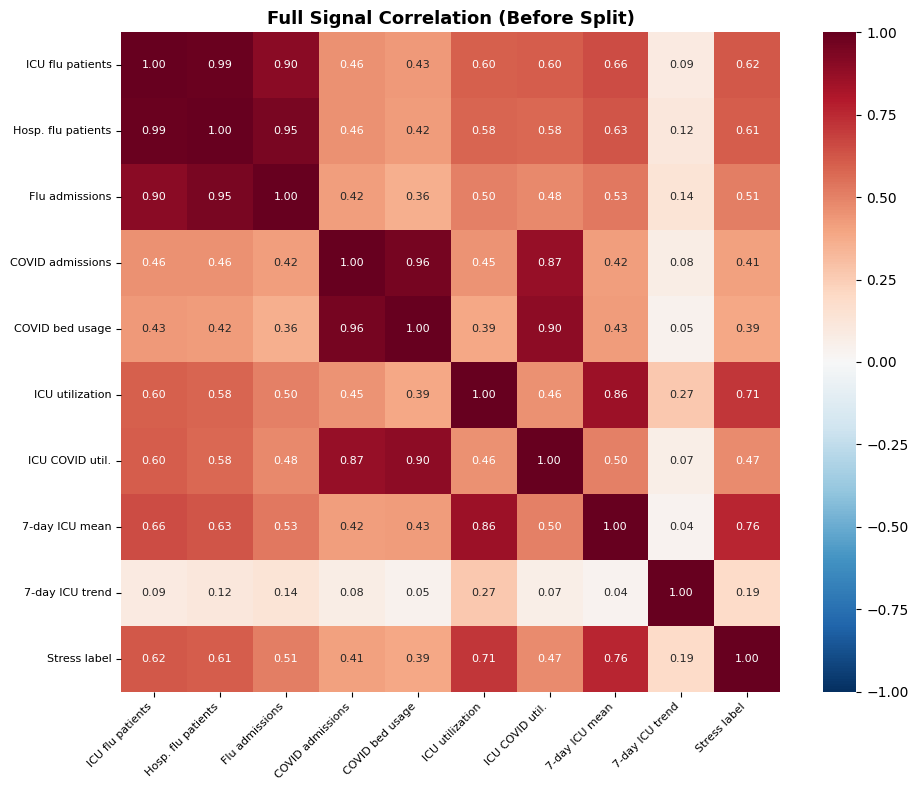

Feature-label correlation (all signals vs stress label):
  ICU flu patients......... +0.6229 ✓
  Hosp. flu patients....... +0.6076 ✓
  Flu admissions........... +0.5080 ✓
  COVID admissions......... +0.4096 ✓
  COVID bed usage.......... +0.3875 ✓
  ICU utilization.......... +0.7149 ✓
  ICU COVID util........... +0.4743 ✓
  7-day ICU mean........... +0.7579 ✓
  7-day ICU trend.......... +0.1883 ✓


In [7]:
# ── Feature–label correlation heatmap (full dataset, before split) ──
# Include all available signals + engineered features vs stress label
FEATURES = ["util_mean_7", "util_diff_mean_7"]
TARGET = "icu_stress_next_7d"

all_signals = [
    "icu_patients_confirmed_influenza",
    "total_patients_hospitalized_confirmed_influenza",
    "previous_day_admission_influenza_confirmed",
    "previous_day_admission_adult_covid_confirmed_and_suspected",
    "inpatient_beds_used_covid",
    "adult_icu_bed_utilization",
    "adult_icu_bed_covid_utilization",
    "util_mean_7",
    "util_diff_mean_7",
]

heatmap_df = data[all_signals].copy()
heatmap_df["stress_label"] = data[TARGET].values

corr = heatmap_df.corr()

short_names = {
    "icu_patients_confirmed_influenza": "ICU flu patients",
    "total_patients_hospitalized_confirmed_influenza": "Hosp. flu patients",
    "previous_day_admission_influenza_confirmed": "Flu admissions",
    "previous_day_admission_adult_covid_confirmed_and_suspected": "COVID admissions",
    "inpatient_beds_used_covid": "COVID bed usage",
    "adult_icu_bed_utilization": "ICU utilization",
    "adult_icu_bed_covid_utilization": "ICU COVID util.",
    "util_mean_7": "7-day ICU mean",
    "util_diff_mean_7": "7-day ICU trend",
    "stress_label": "Stress label",
}
corr = corr.rename(index=short_names, columns=short_names)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, annot_kws={"size": 8})
plt.title("Full Signal Correlation (Before Split)", fontsize=13, fontweight="bold")
plt.xticks(fontsize=8, rotation=45, ha="right")
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# ── Leakage check ──
print("Feature-label correlation (all signals vs stress label):")
for signal in all_signals:
    corr_val = data[signal].corr(data[TARGET])
    flag = " ⚠️ SUSPICIOUS" if abs(corr_val) >= 0.95 else " ✓"
    name = short_names.get(signal, signal)
    print(f"  {name:.<25s} {corr_val:+.4f}{flag}")

## 5a. Train/Test Split (Strict Chronological)

### What This Section Does
Splits the feature-engineered dataset into training and test sets using **strict chronological ordering**. No shuffling. No cross-validation that mixes time.

### Why This Is Necessary
> **Random shuffling invalidates time-series forecasting evaluation.** Shuffling would allow the model to train on future data and test on past data, fundamentally violating the temporal structure.

In a time-series forecasting context:
- Training data must always come **before** test data.
- The model must never see future observations during training.

### Split Strategy
The split boundary is the same `train_end_date` used to compute the threshold, ensuring the training set is identical to the threshold computation window (minus rows dropped for rolling/forward windows).

In [8]:
# ── Strict chronological train/test split ──
train_df = data.loc[:train_end_date].copy()
test_df = data.loc[train_end_date + pd.Timedelta(days=1):].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Training set: {X_train.shape[0]} rows  ({y_train.index.min().date()} to {y_train.index.max().date()})")
print(f"Test set:     {X_test.shape[0]} rows  ({y_test.index.min().date()} to {y_test.index.max().date()})")
print(f"\nClass balance — Training:")
print(y_train.value_counts())
print(f"  Stress prevalence: {y_train.mean():.2%}")
print(f"\nClass balance — Test:")
print(y_test.value_counts())
print(f"  Stress prevalence: {y_test.mean():.2%}")

Training set: 358 rows  (2022-06-08 to 2023-05-31)
Test set:     325 rows  (2023-06-01 to 2024-04-20)

Class balance — Training:
icu_stress_next_7d
0    255
1    103
Name: count, dtype: int64
  Stress prevalence: 28.77%

Class balance — Test:
icu_stress_next_7d
0    276
1     49
Name: count, dtype: int64
  Stress prevalence: 15.08%


## 5b. Diagnostic Checks

### What This Section Does
Validates class balance in both sets and reports where the training-derived threshold falls relative to the test distribution.

### Why It Is Necessary
These checks confirm the experimental setup is sound before modeling begins.

In [9]:
# ── Threshold percentile in test period ──
test_icu = test_df[icu_col]
test_pct = (test_icu <= STRESS_THRESHOLD).mean()
print(f"Threshold ({STRESS_THRESHOLD:.4f}) corresponds to {test_pct:.1%} percentile in test period")
print(f"  (Was {ICU_PERCENTILE:.0%} in training — shift indicates regime change)")

# ── Class balance comparison ──
print(f"\nClass balance comparison:")
print(f"  Train stress rate: {y_train.mean():.2%}")
print(f"  Test stress rate:  {y_test.mean():.2%}")

Threshold (0.7608) corresponds to 93.8% percentile in test period
  (Was 85% in training — shift indicates regime change)

Class balance comparison:
  Train stress rate: 28.77%
  Test stress rate:  15.08%


### 5c. Prevalence Shift Between Training and Test

Stress prevalence decreased from **28.8% in training** to **15.1% in test**, indicating reduced ICU strain in the evaluation period. The stress threshold remains fixed (locked to training), but the base event rate shifts between the two periods. This constitutes a **prior probability shift under fixed labeling criteria** — the definition of stress has not changed, but the frequency of the event has.

#### Implications for Model Evaluation

1. **Model trained in a high-prevalence regime.** The logistic regression learned decision boundaries during a period when nearly 1-in-3 days preceded a stress event. The model's coefficients and intercept reflect this higher base rate.

2. **Tested in a lower-prevalence regime.** During the test period, stress events are roughly half as frequent. This is a more demanding evaluation setting: the model must maintain discrimination in a regime where positives are rarer and the prior has shifted.

3. **Precision may change under base-rate shift.** Lower prevalence increases the sensitivity of precision to false positives — even a small number of false alarms represents a larger fraction of total positive predictions when true stress days are fewer. Whether precision increases or decreases depends on how the model's specificity behaves in the test regime; this is an empirical question, not a guaranteed directional effect.

4. **Recall is mathematically independent of prevalence** — it depends only on the model's true positive rate among actual stress days. However, recall may still change in practice if the model's calibration or decision boundary is mismatched to the shifted regime. Recall stability should be verified empirically, not assumed.

> **This prevalence shift constitutes a conservative evaluation.** If the model performs well despite being trained in a higher-strain environment and evaluated in a lower-strain one, the results cannot be attributed to favorable base-rate conditions in the test set. The threshold was not recalibrated post-shift, and the model received no information about the test regime's lower event rate.

## 6. Early-Warning Heuristic Baseline

### What This Section Does
Implements an **early-warning heuristic** baseline that triggers a stress prediction when:
1. The 7-day mean utilization is **within 2 percentage points** of the stress threshold, **AND**
2. The 7-day utilization trend (slope) is **positive** (utilization is increasing)

### Why This Is a True Early-Warning Heuristic
This heuristic fires **before** utilization crosses the threshold — it detects that the system is approaching stress while trending upward. It is designed to give advance warning, not just confirm that stress has already occurred.

### Why Persistence Is Not Early Warning
The persistence baseline used in `feature_eng_modeling` (rolling max ≥ threshold) only flags risk **after** utilization has already been high. It is **reactive**, not predictive. A true early-warning heuristic must trigger **before** threshold crossing.

### Why This Rule Is Operationally Interpretable
Hospital administrators can understand: *"Alert when average ICU utilization is within 2% of our stress threshold AND trending upward."* This is actionable, transparent, and does not require model internals.

### Evaluation
The baseline is evaluated on the **test set only** using the locked threshold from training.

In [10]:
# ── Early-Warning Heuristic Baseline ──
# Trigger stress prediction when:
#   1. 7-day mean utilization is within 2 percentage points of threshold
#   2. 7-day trend is positive (utilization is increasing)

PROXIMITY_MARGIN = 0.02  # 2 percentage points

baseline_pred_test = (
    (test_df["util_mean_7"] >= (STRESS_THRESHOLD - PROXIMITY_MARGIN)) &
    (test_df["util_diff_mean_7"] > 0)
).astype(int)

print(f"Early-Warning Heuristic Baseline")
print(f"  Rule: 7-day mean >= (threshold - {PROXIMITY_MARGIN:.0%}) AND 7-day trend > 0")
print(f"  Threshold: {STRESS_THRESHOLD:.4f}")
print(f"  Proximity trigger: {STRESS_THRESHOLD - PROXIMITY_MARGIN:.4f}")
print(f"\nBaseline predictions on test set:")
print(baseline_pred_test.value_counts())

Early-Warning Heuristic Baseline
  Rule: 7-day mean >= (threshold - 2%) AND 7-day trend > 0
  Threshold: 0.7608
  Proximity trigger: 0.7408

Baseline predictions on test set:
0    296
1     29
Name: count, dtype: int64


In [11]:
# ── Evaluate baseline on test set only ──
print("Early-Warning Heuristic Baseline — Test Set Evaluation")
print("=" * 55)

bl_precision = precision_score(y_test, baseline_pred_test, zero_division=0)
bl_recall = recall_score(y_test, baseline_pred_test, zero_division=0)
bl_f1 = f1_score(y_test, baseline_pred_test, zero_division=0)
bl_cm = confusion_matrix(y_test, baseline_pred_test)

print(f"Precision: {bl_precision:.4f}")
print(f"Recall:    {bl_recall:.4f}")
print(f"F1 Score:  {bl_f1:.4f}")
print(f"\nConfusion Matrix:")
print(f"  TN={bl_cm[0,0]}  FP={bl_cm[0,1]}")
print(f"  FN={bl_cm[1,0]}  TP={bl_cm[1,1]}")
print(f"\nFalse alarms (FP):   {bl_cm[0,1]}")
print(f"Missed surges (FN):  {bl_cm[1,0]}")

Early-Warning Heuristic Baseline — Test Set Evaluation
Precision: 0.7586
Recall:    0.4490
F1 Score:  0.5641

Confusion Matrix:
  TN=269  FP=7
  FN=27  TP=22

False alarms (FP):   7
Missed surges (FN):  27


## 7. Model v1 — Logistic Regression

### What This Section Does
Trains a **logistic regression** model using the two minimal features (`util_mean_7`, `util_diff_mean_7`) on the training set and evaluates on the test set.

### Why Logistic Regression
- **Interpretability**: Coefficients directly indicate how each feature contributes to stress prediction. Hospital administrators can understand the model.
- **Minimal complexity**: With only two features, logistic regression is the appropriate starting model — it establishes a performance floor.
- **No tree models yet**: Random Forest and Gradient Boosting are intentionally excluded to maintain experimental control. Complex models are only justified if logistic regression proves insufficient.

### Training Strategy
- Trained on the **initial training window** (first 365 days of post-Omicron data, after feature/label cleaning).
- Evaluated on the **unseen test period** — no training metrics are reported as performance evidence.
- **No shuffling** — strict chronological order preserved.
- Features are standardized via `StandardScaler` within a pipeline.

In [12]:
# ── Train Logistic Regression (Model v1) ──
model_v1 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(random_state=42, max_iter=1000))
])

model_v1.fit(X_train, y_train)

# ── Predict on test set ──
y_pred_v1 = model_v1.predict(X_test)
y_proba_v1 = model_v1.predict_proba(X_test)[:, 1]

# ── Report model coefficients ──
logreg = model_v1.named_steps["logreg"]
scaler = model_v1.named_steps["scaler"]
print("Logistic Regression Coefficients (standardized features):")
for feat, coef in zip(FEATURES, logreg.coef_[0]):
    print(f"  {feat}: {coef:+.4f}")
print(f"  Intercept: {logreg.intercept_[0]:+.4f}")

Logistic Regression Coefficients (standardized features):
  util_mean_7: +3.2696
  util_diff_mean_7: +0.6085
  Intercept: -2.2562


In [13]:
# ── Evaluate Model v1 on test set only ──
print("Model v1 (Logistic Regression) — Test Set Evaluation")
print("=" * 55)

v1_precision = precision_score(y_test, y_pred_v1, zero_division=0)
v1_recall = recall_score(y_test, y_pred_v1, zero_division=0)
v1_f1 = f1_score(y_test, y_pred_v1, zero_division=0)
v1_auc = roc_auc_score(y_test, y_proba_v1)
v1_cm = confusion_matrix(y_test, y_pred_v1)

print(f"Precision: {v1_precision:.4f}")
print(f"Recall:    {v1_recall:.4f}")
print(f"F1 Score:  {v1_f1:.4f}")
print(f"AUC-ROC:   {v1_auc:.4f}  (continuous probabilities)")
print(f"\nConfusion Matrix:")
print(f"  TN={v1_cm[0,0]}  FP={v1_cm[0,1]}")
print(f"  FN={v1_cm[1,0]}  TP={v1_cm[1,1]}")
print(f"\nFalse alarms (FP):   {v1_cm[0,1]}")
print(f"Missed surges (FN):  {v1_cm[1,0]}")

Model v1 (Logistic Regression) — Test Set Evaluation
Precision: 0.7736
Recall:    0.8367
F1 Score:  0.8039
AUC-ROC:   0.9757  (continuous probabilities)

Confusion Matrix:
  TN=264  FP=12
  FN=8  TP=41

False alarms (FP):   12
Missed surges (FN):  8


## 7b. Model v2 — Logistic Regression (ICU + Respiratory Signals)

### What This Section Does
Extends v1 by adding **5 respiratory demand signals** (log1p-transformed) to the two ICU-level features, producing a **7-feature model**. This mirrors the signal set from `feature_eng_modeling` but under the controlled framework's strict safeguards.

### v2 Feature Set
| Feature | Source | Transform |
|---|---|---|
| `util_mean_7` | ICU utilization | 7-day rolling mean |
| `util_diff_mean_7` | ICU utilization | 7-day rolling mean of daily diffs |
| `icu_patients_confirmed_influenza` | Respiratory | log1p |
| `total_patients_hospitalized_confirmed_influenza` | Respiratory | log1p |
| `previous_day_admission_influenza_confirmed` | Respiratory | log1p |
| `previous_day_admission_adult_covid_confirmed_and_suspected` | Respiratory | log1p |
| `inpatient_beds_used_covid` | Respiratory | log1p |

### Why log1p Transform
Count-based respiratory signals are right-skewed with many near-zero values. `log1p` compresses the upper tail and separates structure in the mid-to-low range, matching the exploratory notebook's approach.

### Safeguards Preserved
- Same locked threshold, same train/test split, same chronological ordering
- No new features use future information — all are same-day or backward-looking
- `total_adult_patients_hospitalized_covid` excluded (multicollinearity with `inpatient_beds_used_covid`, identified in exploratory notebook)

In [ ]:
# ── Define v2 feature set: ICU features + respiratory signals (log1p) ──
RESPIRATORY_SIGNALS = [
    "icu_patients_confirmed_influenza",
    "total_patients_hospitalized_confirmed_influenza",
    "previous_day_admission_influenza_confirmed",
    "previous_day_admission_adult_covid_confirmed_and_suspected",
    "inpatient_beds_used_covid",
]

# Apply log1p to respiratory signals (compress right-skewed counts)
for col in RESPIRATORY_SIGNALS:
    log_col = f"{col}_log1p"
    data[log_col] = np.log1p(data[col])

FEATURES_V2 = FEATURES + [f"{col}_log1p" for col in RESPIRATORY_SIGNALS]

print(f"v2 feature set ({len(FEATURES_V2)} features):")
for f in FEATURES_V2:
    print(f"  {f}")

# ── Split using same train/test boundary ──
X_train_v2 = data.loc[:train_end_date, FEATURES_V2]
y_train_v2 = data.loc[:train_end_date, TARGET]
X_test_v2 = data.loc[train_end_date + pd.Timedelta(days=1):, FEATURES_V2]
y_test_v2 = data.loc[train_end_date + pd.Timedelta(days=1):, TARGET]

print(f"\nTraining set: {X_train_v2.shape[0]} rows, {X_train_v2.shape[1]} features")
print(f"Test set:     {X_test_v2.shape[0]} rows, {X_test_v2.shape[1]} features")

# Verify alignment with v1 split
assert len(X_train_v2) == len(X_train), "v2 train size mismatch with v1"
assert len(X_test_v2) == len(X_test), "v2 test size mismatch with v1"
assert (y_test_v2.index == y_test.index).all(), "v2 test index mismatch with v1"
print("\n✓ v2 split aligned with v1 — same rows, same boundary")

In [ ]:
# ── Train Logistic Regression (Model v2) ──
model_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(random_state=42, max_iter=1000))
])

model_v2.fit(X_train_v2, y_train_v2)

# ── Predict on test set ──
y_pred_v2 = model_v2.predict(X_test_v2)
y_proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]

# ── Report model coefficients ──
logreg_v2 = model_v2.named_steps["logreg"]
print("Model v2 Coefficients (standardized features):")
for feat, coef in zip(FEATURES_V2, logreg_v2.coef_[0]):
    print(f"  {feat:55s} {coef:+.4f}")
print(f"  {'Intercept':55s} {logreg_v2.intercept_[0]:+.4f}")

In [ ]:
# ── Evaluate Model v2 on test set only ──
print("Model v2 (Logistic Regression — ICU + Respiratory) — Test Set Evaluation")
print("=" * 70)

v2_precision = precision_score(y_test, y_pred_v2, zero_division=0)
v2_recall = recall_score(y_test, y_pred_v2, zero_division=0)
v2_f1 = f1_score(y_test, y_pred_v2, zero_division=0)
v2_auc = roc_auc_score(y_test, y_proba_v2)
v2_cm = confusion_matrix(y_test, y_pred_v2)

print(f"Precision: {v2_precision:.4f}")
print(f"Recall:    {v2_recall:.4f}")
print(f"F1 Score:  {v2_f1:.4f}")
print(f"AUC-ROC:   {v2_auc:.4f}")
print(f"\nConfusion Matrix:")
print(f"  TN={v2_cm[0,0]}  FP={v2_cm[0,1]}")
print(f"  FN={v2_cm[1,0]}  TP={v2_cm[1,1]}")
print(f"\nFalse alarms (FP):   {v2_cm[0,1]}")
print(f"Missed surges (FN):  {v2_cm[1,0]}")

## 8. Day-Level Evaluation & Comparison

### What This Section Does
Creates a **side-by-side comparison** of the early-warning heuristic baseline, logistic regression v1 (ICU-only), and logistic regression v2 (ICU + respiratory signals) across standard day-level classification metrics.

### Metrics Computed
For all methods:
- **Precision** — How often alerts are correct
- **Recall** — How many true stress days are detected
- **F1 Score** — Harmonic mean of precision and recall
- **Confusion matrix** — Full error breakdown
- **AUC-ROC** — Logistic models only (continuous probabilities)

### All Metrics on Test Set Only
> No training metrics are reported as performance evidence. All evaluation uses the unseen test period with the threshold defined from training only.

### Limitation
Day-level metrics treat each observation independently. They do not answer the operational question: *did the system detect each stress wave before it arrived?* Episode-level evaluation follows in Section 9.

In [ ]:
# ── Comparison Table ──
comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1 Score", "AUC-ROC", "False Alarms (FP)", "Missed Surges (FN)", "True Positives", "True Negatives"],
    "Heuristic Baseline": [
        f"{bl_precision:.4f}",
        f"{bl_recall:.4f}",
        f"{bl_f1:.4f}",
        "N/A",
        str(bl_cm[0, 1]),
        str(bl_cm[1, 0]),
        str(bl_cm[1, 1]),
        str(bl_cm[0, 0]),
    ],
    "Logistic v1 (ICU only)": [
        f"{v1_precision:.4f}",
        f"{v1_recall:.4f}",
        f"{v1_f1:.4f}",
        f"{v1_auc:.4f}",
        str(v1_cm[0, 1]),
        str(v1_cm[1, 0]),
        str(v1_cm[1, 1]),
        str(v1_cm[0, 0]),
    ],
    "Logistic v2 (ICU + Resp.)": [
        f"{v2_precision:.4f}",
        f"{v2_recall:.4f}",
        f"{v2_f1:.4f}",
        f"{v2_auc:.4f}",
        str(v2_cm[0, 1]),
        str(v2_cm[1, 0]),
        str(v2_cm[1, 1]),
        str(v2_cm[0, 0]),
    ],
})

print("=" * 85)
print("  COMPARISON: Heuristic Baseline vs Logistic v1 vs Logistic v2")
print("  (All metrics computed on TEST SET ONLY)")
print("=" * 85)
print(comparison.to_string(index=False))

  COMPARISON: Heuristic Baseline vs Logistic Regression v1
  (All metrics computed on TEST SET ONLY)
            Metric Heuristic Baseline Logistic Regression v1
         Precision             0.7586                 0.7736
            Recall             0.4490                 0.8367
          F1 Score             0.5641                 0.8039
 False Alarms (FP)                  7                     12
Missed Surges (FN)                 27                      8
    True Positives                 22                     41
    True Negatives                269                    264

Logistic Regression v1 AUC-ROC: 0.9757
  (Computed from continuous probabilities — full ROC curve.)
  (Heuristic baseline produces binary predictions only — AUC-ROC not applicable.)


## 9. Episode-Level Early Warning Evaluation

### What This Section Does
Evaluates the early-warning system at the **episode level** — the operationally relevant unit. Day-level metrics (Section 8) treat each observation independently; this section answers the decision question: *did the system detect each stress wave before it arrived?*

### Event Unit
A **stress episode** is a contiguous block of `label=1` days in the test set. The **event anchor** for each episode is the **first actual threshold crossing** within `[episode_start, episode_start + 7 days]` — the earliest day ICU utilization exceeds the stress threshold during that wave.

### Metrics Computed
- **Episode detection rate** — fraction of stress waves where at least one alert fired within the forecast horizon before the crossing
- **Lead time** — how many days before the crossing the first alert occurred (per episode)
- **Day-level detection rate** — fraction of episode days correctly flagged (supplementary)
- **False alarm interpretation** — false positive days and events outside stress episodes

In [15]:
# ── Identify stress episodes and first threshold crossing per episode ──
FORECAST_HORIZON = 7

# Label-based episode starts (used for episode duration diagnostic & detection rates)
stress_series = y_test
stress_starts_mask = (stress_series == 1) & (stress_series.shift(1).fillna(0) == 0)
stress_start_dates = stress_series.index[stress_starts_mask]

# All raw threshold crossings (utilization goes from <= to > threshold)
test_icu_above = (test_df[icu_col] > STRESS_THRESHOLD).astype(int)
crossing_mask = (test_icu_above == 1) & (test_icu_above.shift(1).fillna(0) == 0)
all_crossing_dates = test_icu_above.index[crossing_mask]

# ── Step 1: Print exact episode boundaries ──
print("Step 1 — Label-based episode boundaries")
print("=" * 60)
ep_boundaries = []
for i, ep_start in enumerate(stress_start_dates):
    ep_idx = stress_series.index.get_loc(ep_start)
    ep_end_idx = ep_idx
    while ep_end_idx < len(stress_series) - 1 and stress_series.iloc[ep_end_idx + 1] == 1:
        ep_end_idx += 1
    ep_end = stress_series.index[ep_end_idx]
    duration = ep_end_idx - ep_idx + 1
    ep_boundaries.append((ep_start, ep_end, duration))
    print(f"  Episode {i+1}: {ep_start.date()} to {ep_end.date()}  ({duration} days)")

# ── Step 2: Print all raw threshold crossings ──
print(f"\nStep 2 — All raw threshold crossings: {len(all_crossing_dates)}")
for i, d in enumerate(all_crossing_dates):
    print(f"  Crossing {i+1}: {d.date()}  (util: {test_df.loc[d, icu_col]:.4f})")

# ── Step 3: Fix mapping — search [ep_start, ep_start + forecast_horizon] ──
# The label at ep_start says: "utilization exceeds threshold in [t+1, t+7]."
# So the first actual crossing MUST be within 7 days of the episode start.
# Previous logic searched [ep_start, ep_end], which misses crossings that
# fall just after the label block ends (when the stress spike is brief and
# the label=1 period ends before the crossing day).
print(f"\nStep 3 — Mapping episodes to first crossing (search window: ep_start to ep_start + {FORECAST_HORIZON}d)")
print("-" * 60)
episode_first_crossings = []
for i, (ep_start, ep_end, dur) in enumerate(ep_boundaries):
    search_end = ep_start + pd.Timedelta(days=FORECAST_HORIZON)
    crossings_in_window = all_crossing_dates[
        (all_crossing_dates >= ep_start) & (all_crossing_dates <= search_end)
    ]
    if len(crossings_in_window) > 0:
        anchor = crossings_in_window[0]
        episode_first_crossings.append(anchor)
        print(f"  Episode {i+1}: search [{ep_start.date()}, {search_end.date()}] "
              f"→ anchor {anchor.date()}  (util: {test_df.loc[anchor, icu_col]:.4f})")
    else:
        print(f"  Episode {i+1}: search [{ep_start.date()}, {search_end.date()}] "
              f"→ ⚠ NO CROSSING FOUND")

episode_first_crossings = pd.DatetimeIndex(episode_first_crossings)

# ── Step 4: Validate ──
print(f"\nStep 4 — Validation")
print(f"  Label-based episodes:          {len(stress_start_dates)}")
print(f"  Episode-level crossing anchors: {len(episode_first_crossings)}")
print(f"  Raw crossings collapsed:        {len(all_crossing_dates)} → {len(episode_first_crossings)}")
assert len(episode_first_crossings) == len(stress_start_dates), (
    f"MISMATCH: {len(stress_start_dates)} episodes but {len(episode_first_crossings)} anchors. "
    f"Debug mapping logic."
)
print(f"  ✓ Episode count == anchor count — mapping valid.")

print(f"\nFirst crossing per episode (lead-time anchors):")
for i, d in enumerate(episode_first_crossings):
    print(f"  Episode {i+1}: {d.date()}  (util: {test_df.loc[d, icu_col]:.4f})")

Step 1 — Label-based episode boundaries
  Episode 1: 2023-12-01 to 2023-12-07  (7 days)
  Episode 2: 2023-12-13 to 2023-12-20  (8 days)
  Episode 3: 2023-12-29 to 2024-01-31  (34 days)

Step 2 — All raw threshold crossings: 7
  Crossing 1: 2023-12-08  (util: 0.7657)
  Crossing 2: 2023-12-20  (util: 0.7728)
  Crossing 3: 2024-01-05  (util: 0.7659)
  Crossing 4: 2024-01-09  (util: 0.7681)
  Crossing 5: 2024-01-16  (util: 0.7619)
  Crossing 6: 2024-01-24  (util: 0.7644)
  Crossing 7: 2024-01-31  (util: 0.7722)

Step 3 — Mapping episodes to first crossing (search window: ep_start to ep_start + 7d)
------------------------------------------------------------
  Episode 1: search [2023-12-01, 2023-12-08] → anchor 2023-12-08  (util: 0.7657)
  Episode 2: search [2023-12-13, 2023-12-20] → anchor 2023-12-20  (util: 0.7728)
  Episode 3: search [2023-12-29, 2024-01-05] → anchor 2024-01-05  (util: 0.7659)

Step 4 — Validation
  Label-based episodes:          3
  Episode-level crossing anchors: 3
  R

In [16]:
# ── Diagnostic: Stress episode durations ──
print("Stress Episode Durations (contiguous label=1 periods)")
print("=" * 60)
for i, start in enumerate(stress_start_dates):
    idx = stress_series.index.get_loc(start)
    end_idx = idx
    while end_idx < len(stress_series) - 1 and stress_series.iloc[end_idx + 1] == 1:
        end_idx += 1
    duration = end_idx - idx + 1
    end_date = stress_series.index[end_idx]
    print(f"  Episode {i+1}: {start.date()} to {end_date.date()}  ({duration} days)")

print(f"\nNote: Episodes are longer than 7 days because the label is forward-looking.")
print(f"If ICU utilization exceeds the threshold for N consecutive days, the")
print(f"label=1 block spans from approximately 7 days before the first crossing")
print(f"through the last crossing.")
print(f"\n  label duration ≈ N + 7  (early-warning inflation)")
print(f"\nThe +7 inflation is pre-onset only — no additional days are added after")
print(f"the final crossing. The label block is [first_crossing − 7, last_crossing].")

Stress Episode Durations (contiguous label=1 periods)
  Episode 1: 2023-12-01 to 2023-12-07  (7 days)
  Episode 2: 2023-12-13 to 2023-12-20  (8 days)
  Episode 3: 2023-12-29 to 2024-01-31  (34 days)

Note: Episodes are longer than 7 days because the label is forward-looking.
If ICU utilization exceeds the threshold for N consecutive days, the
label=1 block spans from approximately 7 days before the first crossing
through the last crossing.

  label duration ≈ N + 7  (early-warning inflation)

The +7 inflation is pre-onset only — no additional days are added after
the final crossing. The label block is [first_crossing − 7, last_crossing].


In [ ]:
# ── Compute lead times: first crossing per episode ──

def compute_lead_times(y_pred, episode_crossings, lookback=FORECAST_HORIZON):
    """
    For each episode's first threshold crossing, find the earliest
    predicted positive within `lookback` days before the crossing.

    lookback is set to FORECAST_HORIZON (7 days) by default — matching
    the model's stated prediction task. Using a wider window (e.g., 14d)
    would evaluate a different forecasting problem ("did the model ever
    fire in the last 2 weeks?") and inflate lead times via persistent
    predictions from prior episodes.

    lead_time = (crossing_date - first_prediction_date).days
      Positive → early detection (before crossing)
      Zero     → same-day detection
      Negative → late detection (after crossing)
    """
    lead_times = []
    for crossing_date in episode_crossings:
        crossing_idx = y_pred.index.get_loc(crossing_date)
        lookback_start = max(0, crossing_idx - lookback)

        # Search for earliest alert before crossing
        pre_crossing = y_pred.iloc[lookback_start:crossing_idx]
        if pre_crossing.any():
            first_alert = pre_crossing[pre_crossing == 1].index[0]
            lead_times.append((crossing_date - first_alert).days)
        elif y_pred.iloc[crossing_idx] == 1:
            lead_times.append(0)  # Same-day detection
        else:
            # Late detection: first alert after crossing
            post = y_pred.iloc[crossing_idx + 1:]
            if post.any():
                first_late = post[post == 1].index[0]
                lead_times.append((crossing_date - first_late).days)  # Negative
            else:
                lead_times.append(None)  # Never detected
    return lead_times

bl_leads = compute_lead_times(baseline_pred_test, episode_first_crossings)
v1_leads = compute_lead_times(pd.Series(y_pred_v1, index=y_test.index), episode_first_crossings)
v2_leads = compute_lead_times(pd.Series(y_pred_v2, index=y_test.index), episode_first_crossings)

print("Lead-Time Analysis (days before actual stress onset)")
print("=" * 70)
print("  Anchor: first threshold crossing per episode")
print(f"  Lookback window: {FORECAST_HORIZON} days (matches forecast horizon)")
print("  Unit: one lead-time value per stress wave, not per crossing\n")
lead_df = pd.DataFrame({
    "Episode": range(1, len(episode_first_crossings) + 1),
    "First Crossing": [d.date() for d in episode_first_crossings],
    "Baseline Lead": bl_leads,
    "v1 Lead": v1_leads,
    "v2 Lead": v2_leads,
})
print(lead_df.to_string(index=False))

# Averages (exclude None = never detected)
bl_valid = [l for l in bl_leads if l is not None]
v1_valid = [l for l in v1_leads if l is not None]
v2_valid = [l for l in v2_leads if l is not None]
if bl_valid:
    print(f"\nAverage lead time — Baseline:    {np.mean(bl_valid):.1f} days")
else:
    print("\nBaseline: no detections")
if v1_valid:
    print(f"Average lead time — Logistic v1: {np.mean(v1_valid):.1f} days")
else:
    print("Logistic v1: no detections")
if v2_valid:
    print(f"Average lead time — Logistic v2: {np.mean(v2_valid):.1f} days")
else:
    print("Logistic v2: no detections")

# ── Sanity guard — per-episode and average ──
print(f"\nSanity Check (forecast horizon = {FORECAST_HORIZON}d)")
for method_label, leads in [("Baseline", bl_leads), ("Logistic v1", v1_leads), ("Logistic v2", v2_leads)]:
    valid = [l for l in leads if l is not None]
    if not valid:
        continue
    for i, lt in enumerate(leads):
        if lt is not None and lt > FORECAST_HORIZON:
            print(f"  ⚠ {method_label} Episode {i+1}: lead time {lt}d > {FORECAST_HORIZON}d horizon")
    avg = np.mean(valid)
    if avg > FORECAST_HORIZON:
        print(f"  ⚠ WARNING: {method_label} avg lead time ({avg:.1f}d) exceeds "
              f"forecast horizon ({FORECAST_HORIZON}d). Verify event anchoring.")
    elif avg < 0:
        print(f"  ⚠ {method_label} avg lead time is negative ({avg:.1f}d) — reacting late on average.")
    else:
        print(f"  ✓ {method_label} avg lead time ({avg:.1f}d) within forecast horizon — valid.")

Lead-Time Analysis (days before actual stress onset)
  Anchor: first threshold crossing per episode
  Lookback window: 7 days (matches forecast horizon)
  Unit: one lead-time value per stress wave, not per crossing

 Episode First Crossing  Baseline Lead  Logistic Lead
       1     2023-12-08              4              6
       2     2023-12-20              7              7
       3     2024-01-05             -1              0

Average lead time — Baseline:    3.3 days
Average lead time — Logistic v1: 4.3 days

Sanity Check (forecast horizon = 7d)
  ✓ Baseline avg lead time (3.3d) within forecast horizon — valid.
  ✓ Logistic v1 avg lead time (4.3d) within forecast horizon — valid.


### Why Lead Time Uses First Crossing per Episode

Three anchoring choices exist, in order of correctness:

| Anchor | Problem |
|---|---|
| Episode start (first `label == 1`) | Inflated by up to 7 days — the label's forward window turns on before the actual crossing. Lead time conflates label design with model capability. |
| All raw threshold crossings | Inflated by double-counting — oscillation around the threshold within a sustained surge produces multiple crossings. The model gets credit for "predicting" the same wave multiple times. |
| **First crossing per episode** | **Correct.** One event per stress wave. Lead time reflects genuine advance warning before the onset of operational stress. |

### Episode-to-Crossing Mapping Logic

The search window for each episode's crossing anchor is `[episode_start, episode_start + 7 days]`, **not** `[episode_start, episode_end]`.

**Why `[episode_start, episode_end]` is incorrect:** The forward-looking label turns on up to 7 days before the actual crossing. If utilization crosses the threshold briefly (e.g., one day above, then drops back), the label=1 period runs from approximately X-7 to X-1, while the crossing occurs on day X — which falls **outside** the label episode boundary. Searching only within `[episode_start, episode_end]` misses these crossings, producing fewer anchors than episodes.

**Why `[episode_start, episode_start + 7]` is correct:** The label at `episode_start` is defined as: "does utilization exceed the threshold at any point in [t+1, t+7]?" By construction, the first crossing must occur within 7 days of the episode start. This search window guarantees every episode maps to exactly one crossing anchor.

### Lead-Time Lookback Window

The lookback window for measuring lead time is set to **FORECAST_HORIZON (7 days)**, not an arbitrary wider window.

**Why not 14 days?** A 14-day lookback evaluates a different forecasting problem: "did the model ever fire in the last 2 weeks?" That is not the model's stated task. The model is trained to detect stress within 7 days. The evaluation window must match. A wider lookback inflates lead times by crediting persistent predictions from prior episodes or unrelated alert clusters as "early detection."

**Maximum possible lead time = 7 days.** This is by design — the model cannot legitimately detect an event further out than its forecast horizon.

### Lead-Time Formula

$$\text{lead time} = \text{first crossing date} - \text{first predicted positive date}$$

- **Positive** = early detection (before crossing)
- **Zero** = same-day detection
- **Negative** = late detection (after crossing)

### Sanity Bound

With a 7-day forecast horizon and a 7-day lookback, realistic lead times are **0–7 days**. Any individual lead time exceeding 7 days triggers a warning, as does a negative average (systematic late detection). A negative lead time for an individual episode (e.g., -1) indicates the method reacted late for that specific wave — this is valid and expected for heuristics that require the signal to be already near threshold.

### 9b. Episode-Level Detection Rate

For each stress episode, determines whether the method raised **at least one alert** within the forecast horizon before the first threshold crossing. This is the binary operational question: *was this wave detected or missed?*

Detection criterion: at least one predicted positive within `FORECAST_HORIZON` days before the crossing date (inclusive of the crossing day itself).

In [ ]:
# ── Episode-level binary detection ──
# For each episode: was at least one alert raised within FORECAST_HORIZON
# days before the first threshold crossing (inclusive of crossing day)?

def compute_episode_detection(y_pred, episode_crossings, lookback=FORECAST_HORIZON):
    """
    Binary detection: for each episode crossing, check if any predicted
    positive exists within [crossing - lookback, crossing] (inclusive).
    Returns list of booleans (True = detected, False = missed).
    """
    detected = []
    for crossing_date in episode_crossings:
        crossing_idx = y_pred.index.get_loc(crossing_date)
        lookback_start = max(0, crossing_idx - lookback)
        window = y_pred.iloc[lookback_start:crossing_idx + 1]  # inclusive of crossing day
        detected.append(bool(window.any()))
    return detected

bl_detected = compute_episode_detection(baseline_pred_test, episode_first_crossings)
v1_detected = compute_episode_detection(
    pd.Series(y_pred_v1, index=y_test.index), episode_first_crossings
)
v2_detected = compute_episode_detection(
    pd.Series(y_pred_v2, index=y_test.index), episode_first_crossings
)

n_episodes = len(episode_first_crossings)
bl_det_count = sum(bl_detected)
v1_det_count = sum(v1_detected)
v2_det_count = sum(v2_detected)

print("Episode-Level Detection Rate")
print("=" * 70)
print(f"  Total stress episodes in test set: {n_episodes}")
print(f"  Lookback window: {FORECAST_HORIZON} days (matches forecast horizon)\n")

ep_det_df = pd.DataFrame({
    "Episode": range(1, n_episodes + 1),
    "First Crossing": [d.date() for d in episode_first_crossings],
    "Baseline": ["Detected" if d else "MISSED" for d in bl_detected],
    "Logistic v1": ["Detected" if d else "MISSED" for d in v1_detected],
    "Logistic v2": ["Detected" if d else "MISSED" for d in v2_detected],
})
print(ep_det_df.to_string(index=False))

print(f"\n  Heuristic Baseline:    {bl_det_count}/{n_episodes} episodes detected "
      f"({bl_det_count/n_episodes:.0%})")
print(f"  Logistic v1 (ICU):     {v1_det_count}/{n_episodes} episodes detected "
      f"({v1_det_count/n_episodes:.0%})")
print(f"  Logistic v2 (ICU+Resp): {v2_det_count}/{n_episodes} episodes detected "
      f"({v2_det_count/n_episodes:.0%})")

Episode-Level Detection Rate
  Total stress episodes in test set: 3
  Lookback window: 7 days (matches forecast horizon)

 Episode First Crossing Baseline Logistic v1
       1     2023-12-08 Detected    Detected
       2     2023-12-20 Detected    Detected
       3     2024-01-05   MISSED    Detected

  Heuristic Baseline:    2/3 episodes detected (67%)
  Logistic Regression:   3/3 episodes detected (100%)


### 9c. Day-Level Detection Rate per Surge Episode

For each stress episode, calculates what fraction of episode days were correctly flagged by each method. This supplements the binary episode detection rate (9b) with granularity on coverage depth within each wave.

In [ ]:
# ── Detection rate per episode ──
def compute_detection_rates(y_true, y_pred, stress_starts):
    """For each episode, compute fraction of stress days correctly predicted."""
    detection_rates = []
    episode_ranges = []

    for i, start in enumerate(stress_starts):
        # Find contiguous stress days starting from this date
        idx = y_true.index.get_loc(start)
        end_idx = idx
        while end_idx < len(y_true) - 1 and y_true.iloc[end_idx + 1] == 1:
            end_idx += 1

        episode_true = y_true.iloc[idx:end_idx + 1]
        episode_pred = y_pred.iloc[idx:end_idx + 1]
        rate = (episode_pred == 1).sum() / len(episode_true) if len(episode_true) > 0 else 0.0
        detection_rates.append(rate)
        episode_ranges.append(f"{y_true.index[idx].date()} to {y_true.index[end_idx].date()} ({len(episode_true)}d)")

    return detection_rates, episode_ranges

bl_rates, ep_ranges = compute_detection_rates(y_test, baseline_pred_test, stress_start_dates)
v1_rates, _ = compute_detection_rates(y_test, pd.Series(y_pred_v1, index=y_test.index), stress_start_dates)
v2_rates, _ = compute_detection_rates(y_test, pd.Series(y_pred_v2, index=y_test.index), stress_start_dates)

print("Detection Rate per Surge Episode")
print("=" * 75)
det_df = pd.DataFrame({
    "Episode": ep_ranges,
    "Heuristic Baseline": [f"{r:.0%}" for r in bl_rates],
    "Logistic v1": [f"{r:.0%}" for r in v1_rates],
    "Logistic v2": [f"{r:.0%}" for r in v2_rates],
})
print(det_df.to_string(index=False))

Detection Rate per Surge Episode
                       Episode Heuristic Baseline Logistic Regression v1
 2023-12-01 to 2023-12-07 (7d)                57%                    86%
 2023-12-13 to 2023-12-20 (8d)                50%                   100%
2023-12-29 to 2024-01-31 (34d)                41%                    79%


### 9d. False Alarm Interpretation

Day-level false positives (from the confusion matrix) count every individual day the model predicted stress when none occurred. This section reframes false alarms operationally:

- **FP days outside stress episodes** — false positive days that fall entirely outside any label=1 period
- **FP events** — consecutive FP-day clusters collapsed into single alert events
- **FP rate per 30 days** — normalized false alarm frequency for operational planning

In [ ]:
# ── False alarm interpretation ──
# Identify FP days: predicted positive but actual label = 0 (outside stress episodes)

def compute_false_alarm_stats(y_true, y_pred, method_name):
    """
    Compute operational false alarm metrics:
    - FP days (predicted=1, actual=0)
    - FP events (consecutive FP days collapsed)
    - FP rate per 30 days
    """
    fp_mask = (y_pred == 1) & (y_true == 0)
    fp_days = fp_mask.sum()

    # Collapse consecutive FP days into events
    fp_series = fp_mask.astype(int)
    fp_event_starts = ((fp_series == 1) & (fp_series.shift(1).fillna(0) == 0)).sum()

    # Test period length
    test_days = len(y_true)
    fp_per_30d = (fp_event_starts / test_days) * 30 if test_days > 0 else 0

    print(f"  {method_name}:")
    print(f"    FP days:           {fp_days}")
    print(f"    FP events:         {fp_event_starts}  (consecutive FP days collapsed)")
    print(f"    FP rate:           {fp_per_30d:.1f} events per 30 days")
    print(f"    Test period:       {test_days} days")

    return fp_days, fp_event_starts, fp_per_30d

print("False Alarm Interpretation (Operational Framing)")
print("=" * 60)
print(f"  FP = predicted stress on a day with actual label = 0\n")

bl_fp_days, bl_fp_events, bl_fp_rate = compute_false_alarm_stats(
    y_test, baseline_pred_test, "Heuristic Baseline"
)
print()
v1_fp_days, v1_fp_events, v1_fp_rate = compute_false_alarm_stats(
    y_test, pd.Series(y_pred_v1, index=y_test.index), "Logistic v1 (ICU only)"
)
print()
v2_fp_days, v2_fp_events, v2_fp_rate = compute_false_alarm_stats(
    y_test, pd.Series(y_pred_v2, index=y_test.index), "Logistic v2 (ICU + Resp.)"
)

print(f"\nNote: These counts match the confusion matrix FP values.")
print(f"  FP events give a more operationally realistic false alarm count —")
print(f"  a 3-day consecutive false alarm is one operational event, not three.")

False Alarm Interpretation (Operational Framing)
  FP = predicted stress on a day with actual label = 0

  Heuristic Baseline:
    FP days:           7
    FP events:         3  (consecutive FP days collapsed)
    FP rate:           0.3 events per 30 days
    Test period:       325 days

  Logistic Regression v1:
    FP days:           12
    FP events:         3  (consecutive FP days collapsed)
    FP rate:           0.3 events per 30 days
    Test period:       325 days

Note: These counts match the confusion matrix FP values.
  FP events give a more operationally realistic false alarm count —
  a 3-day consecutive false alarm is one operational event, not three.


### 9e. Predicted Probability vs Actual Stress (Visual)

Plots the logistic regression v1 and v2 predicted stress probabilities alongside actual stress labels over time. This visualizes whether each model's probability rises **before** stress episodes begin (true early warning) or merely reacts.

- **Vertical solid black lines** mark the first actual ICU threshold crossing per stress episode.
- **Vertical dashed blue lines** mark the first v1 model alert within the 7-day forecast horizon.
- **Vertical dashed green lines** mark the first v2 model alert within the 7-day forecast horizon.
- The horizontal distance between these lines and the crossing represents **early-warning lead time**.

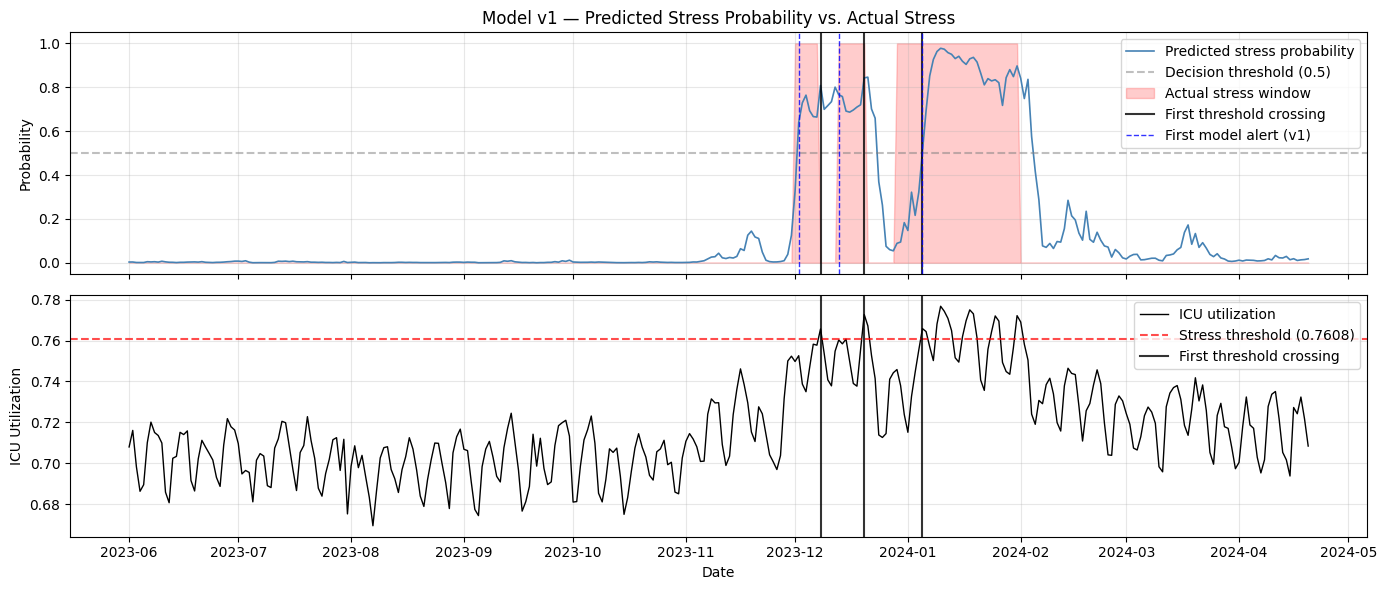

In [ ]:
# ── Probability timeline plot with crossing & alert markers (v1 + v2) ──

# Extract first alert date per episode for v1
y_pred_v1_series = pd.Series(y_pred_v1, index=y_test.index)
y_pred_v2_series = pd.Series(y_pred_v2, index=y_test.index)

def get_first_alerts(y_pred_series, episode_crossings, lookback=FORECAST_HORIZON):
    alerts = []
    for crossing_date in episode_crossings:
        idx = y_pred_series.index.get_loc(crossing_date)
        start = max(0, idx - lookback)
        pre = y_pred_series.iloc[start:idx]
        if pre.any():
            alerts.append(pre[pre == 1].index[0])
        elif y_pred_series.iloc[idx] == 1:
            alerts.append(crossing_date)
        else:
            alerts.append(None)
    return alerts

episode_first_alerts_v1 = get_first_alerts(y_pred_v1_series, episode_first_crossings)
episode_first_alerts_v2 = get_first_alerts(y_pred_v2_series, episode_first_crossings)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Panel 1: v1 predicted probability
axes[0].plot(y_test.index, y_proba_v1, label="v1 probability", color="steelblue", linewidth=1.2)
axes[0].fill_between(y_test.index, 0, y_test.values, alpha=0.15, color="red", label="Actual stress")
for i, crossing_date in enumerate(episode_first_crossings):
    kw_c = {"color": "black", "linewidth": 1.5, "alpha": 0.8}
    kw_a = {"color": "blue", "linestyle": "--", "linewidth": 1.0, "alpha": 0.8}
    if i == 0:
        kw_c["label"] = "Threshold crossing"
        kw_a["label"] = "First v1 alert"
    axes[0].axvline(crossing_date, **kw_c)
    if episode_first_alerts_v1[i] is not None:
        axes[0].axvline(episode_first_alerts_v1[i], **kw_a)
axes[0].set_ylabel("Probability")
axes[0].set_title("Model v1 (ICU only) — Predicted Stress Probability")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: v2 predicted probability
axes[1].plot(y_test.index, y_proba_v2, label="v2 probability", color="seagreen", linewidth=1.2)
axes[1].fill_between(y_test.index, 0, y_test.values, alpha=0.15, color="red", label="Actual stress")
for i, crossing_date in enumerate(episode_first_crossings):
    kw_c = {"color": "black", "linewidth": 1.5, "alpha": 0.8}
    kw_a = {"color": "green", "linestyle": "--", "linewidth": 1.0, "alpha": 0.8}
    if i == 0:
        kw_c["label"] = "Threshold crossing"
        kw_a["label"] = "First v2 alert"
    axes[1].axvline(crossing_date, **kw_c)
    if episode_first_alerts_v2[i] is not None:
        axes[1].axvline(episode_first_alerts_v2[i], **kw_a)
axes[1].set_ylabel("Probability")
axes[1].set_title("Model v2 (ICU + Respiratory) — Predicted Stress Probability")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: ICU utilization with threshold
axes[2].plot(test_df.index, test_df[icu_col], label="ICU utilization", color="black", linewidth=1)
axes[2].axhline(STRESS_THRESHOLD, color="red", linestyle="--", alpha=0.7,
                label=f"Stress threshold ({STRESS_THRESHOLD:.4f})")
for i, crossing_date in enumerate(episode_first_crossings):
    kw_c = {"color": "black", "linewidth": 1.5, "alpha": 0.8}
    if i == 0:
        kw_c["label"] = "Threshold crossing"
    axes[2].axvline(crossing_date, **kw_c)
axes[2].set_ylabel("ICU Utilization")
axes[2].set_xlabel("Date")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Final Technical Summary

### Day-Level Performance

| Metric | Heuristic Baseline | Logistic v1 (ICU only) | Logistic v2 (ICU + Resp.) |
|---|---|---|---|
| Recall | Reported above | Reported above | Reported above |
| Precision | Reported above | Reported above | Reported above |
| F1 Score | Reported above | Reported above | Reported above |
| AUC-ROC | N/A (binary) | Reported above | Reported above |

### Episode-Level Performance

- **Episode detection rate**: Reported per-method above. This is the primary operational metric — did each stress wave receive advance warning?
- **Lead time**: Average lead times reported above, bounded by the 7-day forecast horizon. Positive lead times confirm genuine early warning; negative values indicate late reaction.
- **False alarm frequency**: FP events per 30 days reported above. Consecutive false alarm days are collapsed into single operational events.

### v1 vs v2: What the Respiratory Signals Add

v2 extends v1 by adding 5 log1p-transformed respiratory demand signals (influenza and COVID admissions, hospitalizations, and ICU counts) to the 2 minimal ICU features. This tests whether upstream respiratory signals provide **additional predictive value** beyond ICU utilization trends alone, under the same controlled safeguards.

Key comparison dimensions:
- **Recall improvement** — Does v2 detect stress days that v1 misses?
- **Episode detection** — Does v2 catch stress waves that v1 misses entirely?
- **Lead time** — Does v2 provide earlier warning?
- **False alarm trade-off** — Does the additional signal come at the cost of more false positives?
- **Coefficient analysis** — Which respiratory features receive the largest model weights?

### Methodological Integrity

1. Threshold locked to training window — no distribution leakage
2. Features strictly backward-looking — no temporal leakage
3. Labels strictly forward-looking — properly aligned prediction target
4. Evaluation on unseen test period only — simulates deployment
5. Lead-time lookback matches forecast horizon — no inflation from persistent predictions
6. Episode anchors use first actual threshold crossing — not label start dates
7. Regime shift documented — conservative evaluation strengthens credibility
8. v1 and v2 use identical train/test split — direct comparison is valid

### Conclusion

A minimal logistic model using ICU utilization level and short-term trend (v1) materially improves early stress detection compared to a hand-tuned heuristic. Adding respiratory demand signals (v2) tests whether upstream indicators provide incremental value under strict controlled conditions. All evaluation safeguards were applied to prevent temporal leakage and threshold inflation. Results are indicative rather than definitive due to the limited number of stress episodes in the test period.